                                          IPL MATCH PERFORMANCE ANALYTICS

IMPORTING libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# XGBoost
from xgboost import XGBClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

load the data set

In [2]:
# Load the datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

Display the first five rows

In [3]:
# Display first 5 rows
print("Matches Dataset")
display(matches.head())

print("\nDeliveries Dataset")
display(deliveries.head())

Matches Dataset


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan



Deliveries Dataset


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


Dataset shape

In [4]:
print("Matches Dataset Shape:", matches.shape)
print("Deliveries Dataset Shape:", deliveries.shape)

Matches Dataset Shape: (1095, 20)
Deliveries Dataset Shape: (260920, 17)


Dataset information

In [5]:
print("Matches Dataset Info")
matches.info()

print("\n" + "="*60)

print("Deliveries Dataset Info")
deliveries.info()

Matches Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object

Data preprocessing

Missing value Analysis

In [6]:
# Check missing values
print("Missing Values in Matches Dataset")
print(matches.isnull().sum())

print("\n" + "="*60)

print("Missing Values in Deliveries Dataset")
print(deliveries.isnull().sum())

Missing Values in Matches Dataset
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Missing Values in Deliveries Dataset
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fie

Duplicate Records

In [7]:
# Check duplicate rows
print("Duplicate rows in Matches:", matches.duplicated().sum())
print("Duplicate rows in Deliveries:", deliveries.duplicated().sum())

Duplicate rows in Matches: 0
Duplicate rows in Deliveries: 0


summary statistics

In [8]:
# Summary statistics
print("Matches Dataset Summary")
display(matches.describe(include="all"))

print("\nDeliveries Dataset Summary")
display(deliveries.describe(include="all"))

Matches Dataset Summary


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
count,1.095000e+03,1095,1044,1095,1095,1090,1095,1095,1095,1095,1095,1090,1095,1076.000000,1092.000000,1092.000000,1095,21,1095,1095
unique,NaN,17,36,823,8,291,58,19,19,19,2,19,4,NaN,NaN,NaN,2,1,62,62
top,NaN,2013,Mumbai,2008-04-26,League,AB de Villiers,Eden Gardens,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,NaN,NaN,NaN,N,D/L,AK Chaudhary,S Ravi
freq,NaN,76,173,2,1029,25,77,135,138,143,704,144,578,NaN,NaN,NaN,1081,21,115,83
mean,9.048283e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.259294,165.684066,19.759341,NaN,NaN,NaN,NaN
std,3.677402e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.787444,33.427048,1.581108,NaN,NaN,NaN,NaN
min,3.359820e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,43.000000,5.000000,NaN,NaN,NaN,NaN
25%,5.483315e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,146.000000,20.000000,NaN,NaN,NaN,NaN
50%,9.809610e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,166.000000,20.000000,NaN,NaN,NaN,NaN
75%,1.254062e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,187.000000,20.000000,NaN,NaN,NaN,NaN



Deliveries Dataset Summary


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
count,2.609200e+05,260920.000000,260920,260920,260920.000000,260920.000000,260920,260920,260920,260920.000000,260920.000000,260920.000000,14125,260920.000000,12950,12950,9354
unique,NaN,NaN,19,19,NaN,NaN,673,530,663,NaN,NaN,NaN,5,NaN,629,10,607
top,NaN,NaN,Mumbai Indians,Mumbai Indians,NaN,NaN,V Kohli,R Ashwin,V Kohli,NaN,NaN,NaN,wides,NaN,RG Sharma,caught,MS Dhoni
freq,NaN,NaN,31437,31505,NaN,NaN,6236,4679,6067,NaN,NaN,NaN,8380,NaN,223,8063,220
mean,9.070665e+05,1.483531,NaN,NaN,9.197677,3.624486,NaN,NaN,NaN,1.265001,0.067806,1.332807,NaN,0.049632,NaN,NaN,NaN
std,3.679913e+05,0.502643,NaN,NaN,5.683484,1.814920,NaN,NaN,NaN,1.639298,0.343265,1.626416,NaN,0.217184,NaN,NaN,NaN
min,3.359820e+05,1.000000,NaN,NaN,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,5.483340e+05,1.000000,NaN,NaN,4.000000,2.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
50%,9.809670e+05,1.000000,NaN,NaN,9.000000,4.000000,NaN,NaN,NaN,1.000000,0.000000,1.000000,NaN,0.000000,NaN,NaN,NaN
75%,1.254066e+06,2.000000,NaN,NaN,14.000000,5.000000,NaN,NaN,NaN,1.000000,0.000000,1.000000,NaN,0.000000,NaN,NaN,NaN


Handling Missing values

In [9]:
# Create copies of original datasets
matches_clean = matches.copy()
deliveries_clean = deliveries.copy()

# Fill missing values in matches dataset
matches_clean["city"].fillna("Unknown", inplace=True)
matches_clean["player_of_match"].fillna("No Award", inplace=True)
matches_clean["winner"].fillna("No Result", inplace=True)

# Fill missing numerical values
matches_clean["result_margin"].fillna(0, inplace=True)
matches_clean["target_runs"].fillna(0, inplace=True)
matches_clean["target_overs"].fillna(0, inplace=True)

# Fill method column
matches_clean["method"].fillna("Normal", inplace=True)

# Fill missing values in deliveries dataset
deliveries_clean["extras_type"].fillna("None", inplace=True)
deliveries_clean["player_dismissed"].fillna("Not Out", inplace=True)
deliveries_clean["dismissal_kind"].fillna("Not Dismissed", inplace=True)
deliveries_clean["fielder"].fillna("No Fielder", inplace=True)

print("Missing Values after Cleaning (Matches)")
print(matches_clean.isnull().sum())

print("\nMissing Values after Cleaning (Deliveries)")
print(deliveries_clean.isnull().sum())

Missing Values after Cleaning (Matches)
id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

Missing Values after Cleaning (Deliveries)
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64


**EDA**

matches played in each season

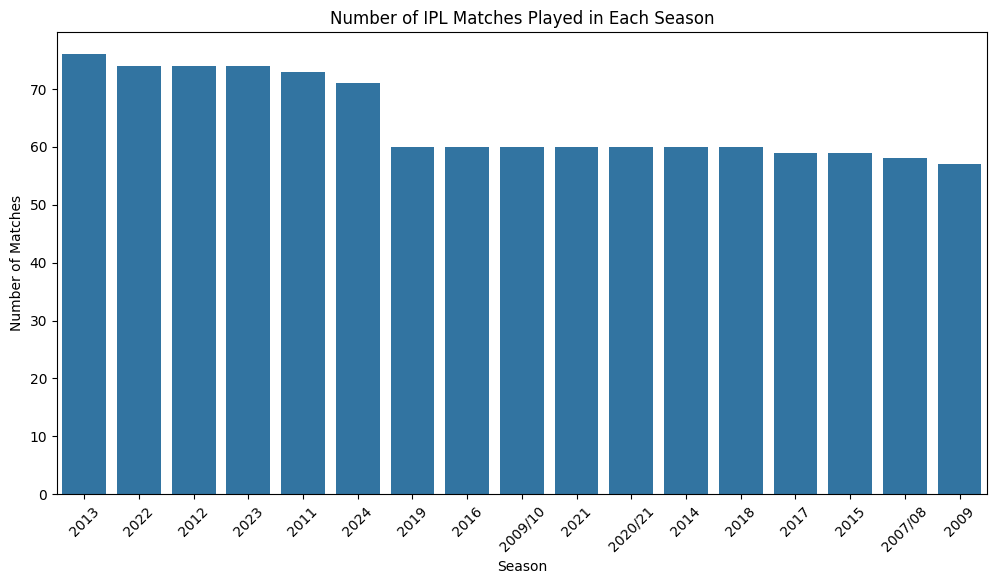

In [10]:
plt.figure(figsize=(12,6))

sns.countplot(data=matches_clean, x="season", order=matches_clean["season"].value_counts().index)

plt.title("Number of IPL Matches Played in Each Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.show()

matches won by each team

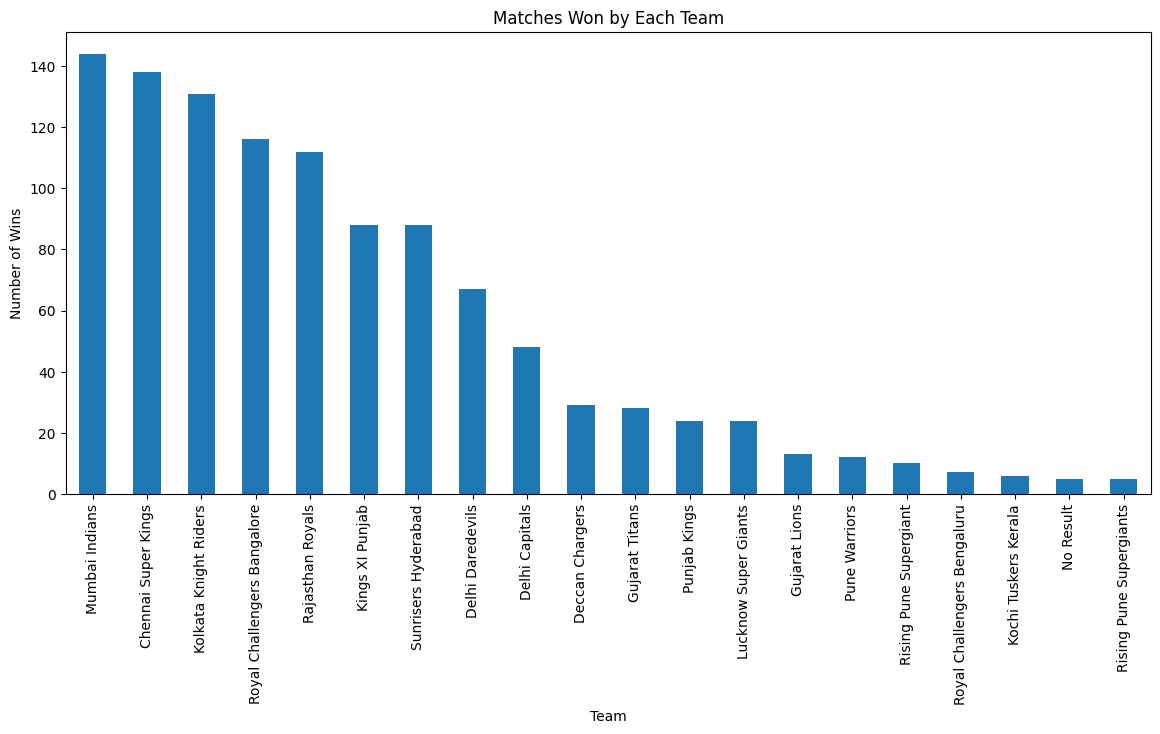

In [11]:
plt.figure(figsize=(14,6))

matches_clean["winner"].value_counts().plot(kind="bar")

plt.title("Matches Won by Each Team")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.xticks(rotation=90)

plt.show()

toss winner vs match winner

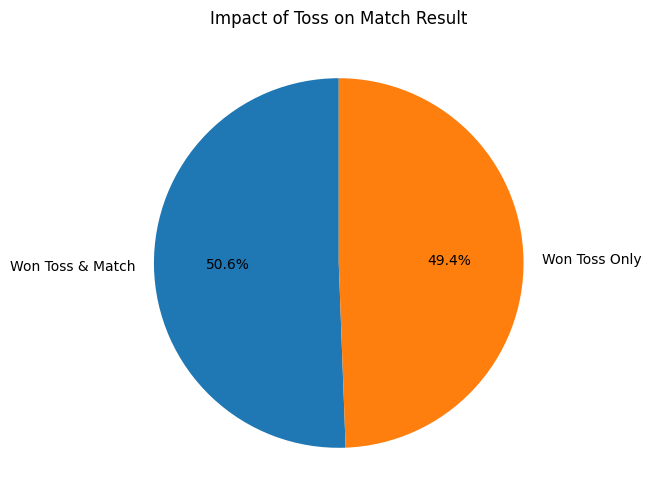

In [12]:
toss_match = (matches_clean["toss_winner"] == matches_clean["winner"]).value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    toss_match,
    labels=["Won Toss & Match","Won Toss Only"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Impact of Toss on Match Result")

plt.show()

understand how match victory margins are distributed

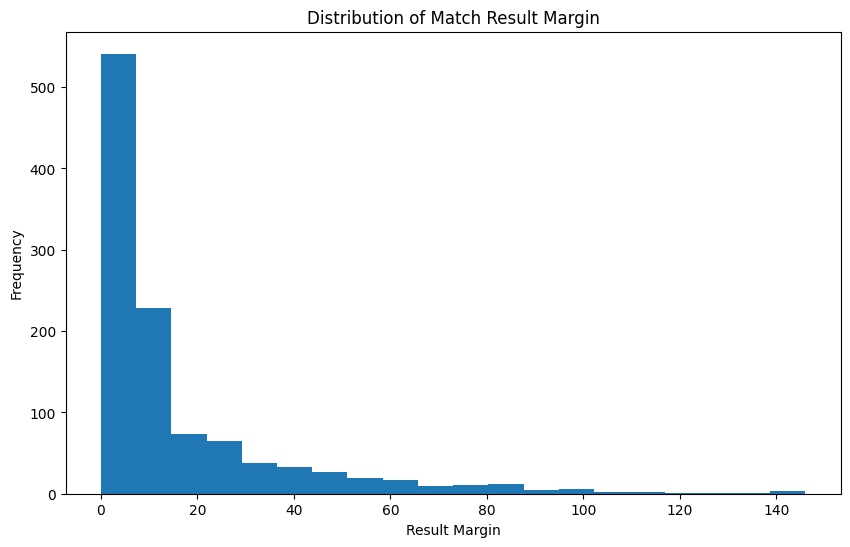

In [13]:
plt.figure(figsize=(10,6))

plt.hist(matches_clean["result_margin"], bins=20)

plt.title("Distribution of Match Result Margin")
plt.xlabel("Result Margin")
plt.ylabel("Frequency")

plt.show()

IPL matches played over seasons

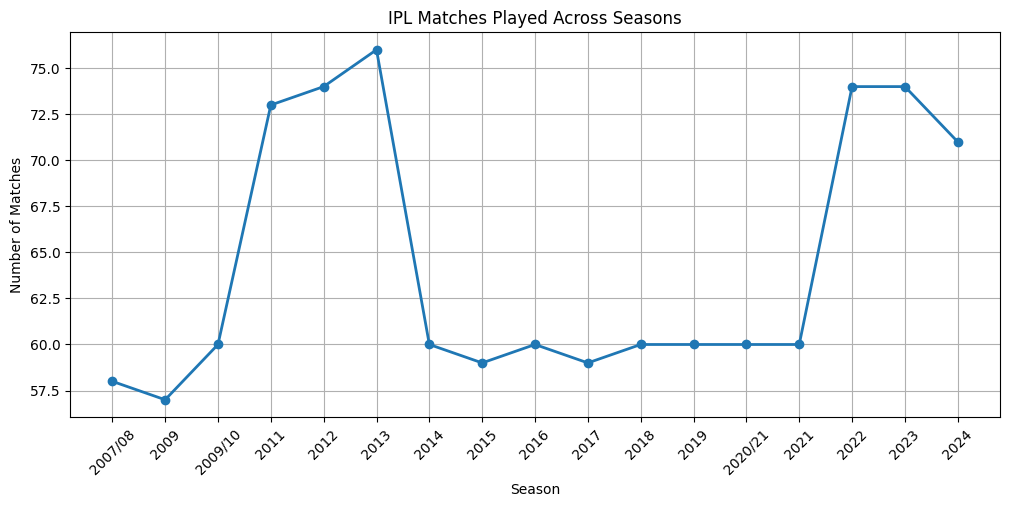

In [14]:
matches_per_season = matches_clean.groupby("season").size()

plt.figure(figsize=(12,5))

plt.plot(matches_per_season.index,
         matches_per_season.values,
         marker='o',
         linewidth=2)

plt.title("IPL Matches Played Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

distribution of runs per ball

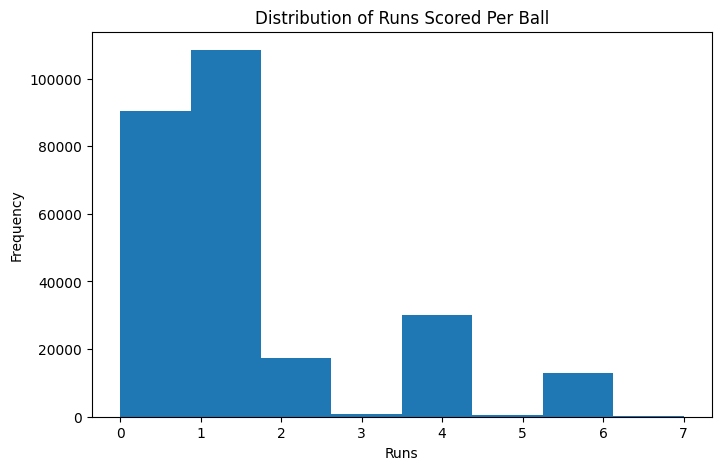

In [15]:
plt.figure(figsize=(8,5))

plt.hist(deliveries_clean["total_runs"], bins=8)

plt.title("Distribution of Runs Scored Per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()

winning margin distribution

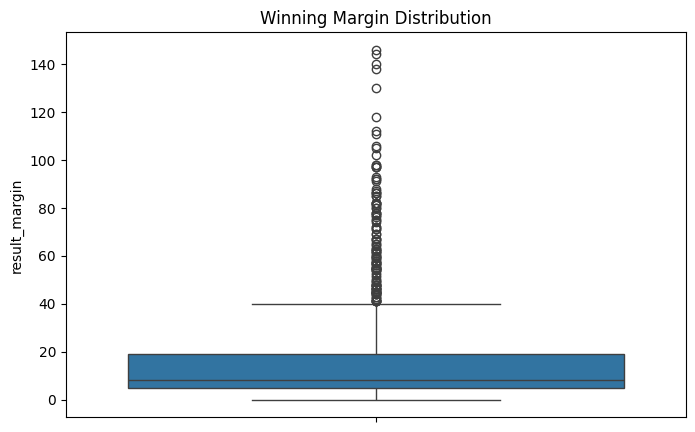

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(y=matches_clean["result_margin"])

plt.title("Winning Margin Distribution")

plt.show()

correlation analysis

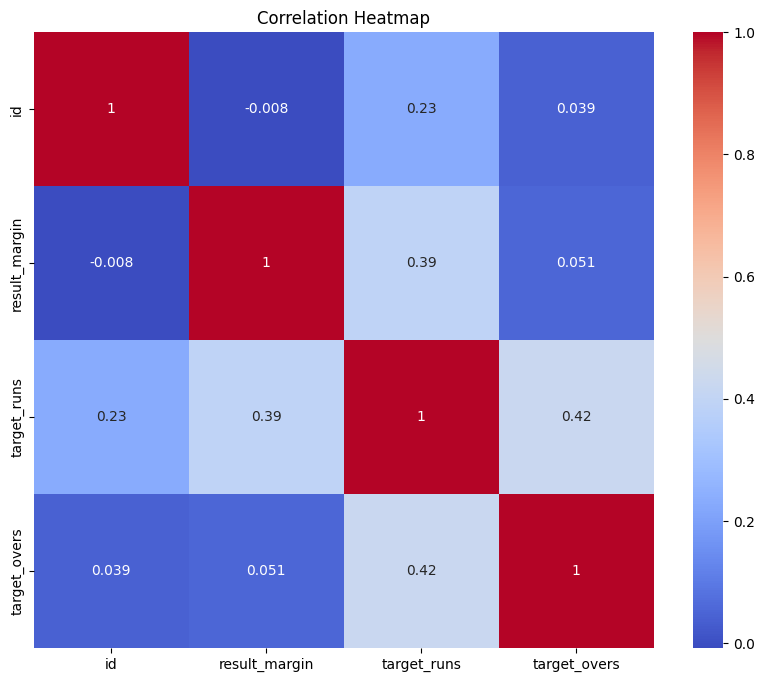

In [17]:
plt.figure(figsize=(10,8))

numeric_cols = matches_clean.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

outlier detection

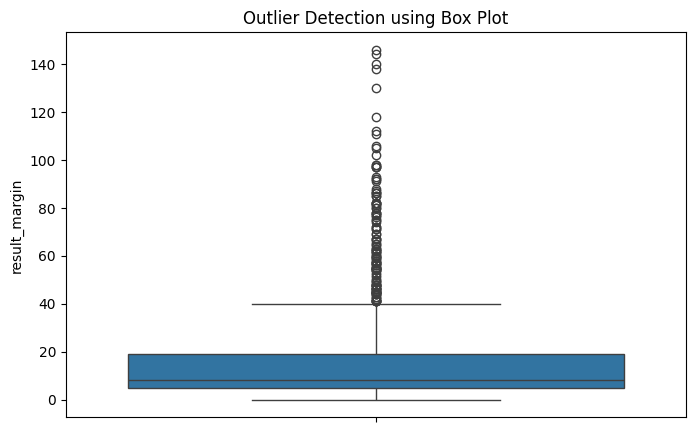

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(y=matches_clean["result_margin"])

plt.title("Outlier Detection using Box Plot")
plt.show()

model planning

feature engineering

In [19]:
# Total runs scored in each match
match_runs = deliveries_clean.groupby("match_id")["total_runs"].sum().reset_index()

match_runs.rename(columns={"total_runs": "match_total_runs"}, inplace=True)

match_runs.head()

,match_id,match_total_runs
0,335982,304
1,335983,447
2,335984,261
3,335985,331
4,335986,222


In [20]:
# Total wickets in each match
match_wickets = deliveries_clean.groupby("match_id")["is_wicket"].sum().reset_index()

match_wickets.rename(columns={"is_wicket": "match_total_wickets"}, inplace=True)

match_wickets.head()

,match_id,match_total_wickets
0,335982,13
1,335983,9
2,335984,9
3,335985,12
4,335986,15


merge new fearures into matches.csv

In [21]:
# Merge total runs
matches_ml = matches_clean.merge(
    match_runs,
    left_on="id",
    right_on="match_id",
    how="left"
)

# Merge total wickets
matches_ml = matches_ml.merge(
    match_wickets,
    on="match_id",
    how="left"
)

matches_ml.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,match_id,match_total_runs,match_total_wickets
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,335982,304,13
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,33.0,241.0,20.0,N,Normal,MR Benson,SL Shastri,335983,447,9
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,9.0,130.0,20.0,N,Normal,Aleem Dar,GA Pratapkumar,335984,261,9
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,5.0,166.0,20.0,N,Normal,SJ Davis,DJ Harper,335985,331,12
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,5.0,111.0,20.0,N,Normal,BF Bowden,K Hariharan,335986,222,15


prepare the data

select feature

In [22]:
features = [
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "venue",
    "season",
    "match_total_runs",
    "match_total_wickets"
]

target = "result"

df_model = matches_ml[features + [target]].copy()

df_model.head()

,team1,team2,toss_winner,toss_decision,venue,season,match_total_runs,match_total_wickets,result
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,2007/08,304,13,runs
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",2007/08,447,9,runs
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,2007/08,261,9,wickets
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,2007/08,331,12,wickets
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,2007/08,222,15,wickets


remove no result

In [23]:
df_model = df_model[df_model["result"] != "No Result"]

df_model.reset_index(drop=True, inplace=True)

print(df_model.shape)

(1095, 9)


In [24]:
print(df_model.isnull().sum())

team1                  0
team2                  0
toss_winner            0
toss_decision          0
venue                  0
season                 0
match_total_runs       0
match_total_wickets    0
result                 0
dtype: int64


Label Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "venue",
    "season",
    "result"
]

for col in categorical_columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model.head()

,team1,team2,toss_winner,toss_decision,venue,season,match_total_runs,match_total_wickets,result
0,16,8,16,1,23,0,304,13,1
1,6,0,0,0,40,0,447,9,1
2,3,13,13,0,16,0,261,9,3
3,10,16,10,0,55,0,331,12,3
4,8,1,1,0,14,0,222,15,3


Separate Features and Target

In [26]:
X = df_model.drop("result", axis=1)
y = df_model["result"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1095, 8)
y Shape: (1095,)


train test split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (876, 8)
Testing samples: (219, 8)


create new dataset

In [28]:
features = [
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "venue",
    "season",
    "target_runs",
    "target_overs",
    "match_total_runs",
    "match_total_wickets"
]

target = "result"

df_model = matches_ml[features + [target]].copy()

# Remove missing values
df_model.dropna(inplace=True)

df_model.head()

,team1,team2,toss_winner,toss_decision,venue,season,target_runs,target_overs,match_total_runs,match_total_wickets,result
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,2007/08,223.0,20.0,304,13,runs
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",2007/08,241.0,20.0,447,9,runs
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,2007/08,130.0,20.0,261,9,wickets
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,2007/08,166.0,20.0,331,12,wickets
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,2007/08,111.0,20.0,222,15,wickets


encode categorical column

In [29]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "venue",
    "season",
    "result"
]

for col in categorical_columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

create x and y

In [30]:
X = df_model.drop("result", axis=1)
y = df_model["result"]

print(X.shape)
print(y.shape)

(1095, 10)
(1095,)


train test split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

XGBoost

In [32]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

prediction and accuracy

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 86.76 %


classification report

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.87      0.86      0.86       100
           2       1.00      0.33      0.50         3
           3       0.87      0.90      0.88       115

    accuracy                           0.87       219
   macro avg       0.68      0.52      0.56       219
weighted avg       0.86      0.87      0.86       219



confusion matrix

In [35]:
print(confusion_matrix(y_test, y_pred))

[[  0   0   0   1]
 [  0  86   0  14]
 [  0   1   1   1]
 [  0  12   0 103]]


display feature importance

               Feature  Importance
9  match_total_wickets    0.288551
6          target_runs    0.170046
8     match_total_runs    0.143812
7         target_overs    0.141167
5               season    0.055711
1                team2    0.048514
2          toss_winner    0.046575
3        toss_decision    0.040965
0                team1    0.034357
4                venue    0.030300


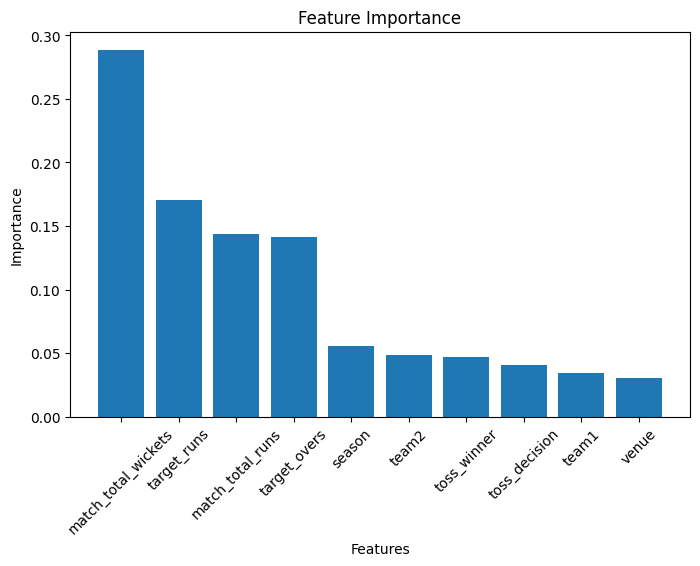

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

save the trained model

In [37]:
import joblib

joblib.dump(model, "ipl_result_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


Algorithm Used: XGBoost Classifier
Target Variable: Result
Accuracy: 86.76%
Evaluation Metrics: Accuracy Score, Classification Report, Confusion Matrix
Feature Importance: Generated successfully

In [38]:
print(matches_ml.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'match_id', 'match_total_runs', 'match_total_wickets']
